<a href="https://colab.research.google.com/github/sinsun030508/ai/blob/main/%ED%94%BC%EC%A7%80%EC%BB%AC_ai_10%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

차원 축소

LDA 변환 후 데이터 형태:  (150, 3)

각 성분의 클래스 판별 기여도(설명력):
[0.9912126 0.0087874]


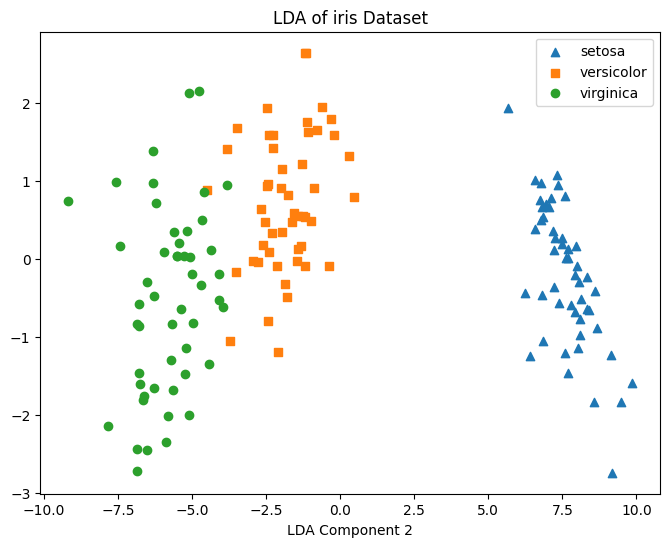

In [7]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt


iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
iris_lda = lda.fit_transform(X_scaled, y)

df_lda = pd.DataFrame(iris_lda, columns= ['LDA_Component_1', 'LDA_Component_2'])
df_lda['target'] = y

print("LDA 변환 후 데이터 형태: ", df_lda.shape)
print("\n각 성분의 클래스 판별 기여도(설명력):")
print(lda.explained_variance_ratio_)

plt.figure(figsize=(8,6))
markers = ['^', 's', 'o']

for i, marker in enumerate(markers):
  x_data = df_lda[df_lda['target'] == i] ['LDA_Component_1']
  y_data = df_lda[df_lda['target'] == i] ['LDA_Component_2']
  plt.scatter(x_data, y_data, marker=marker, label=iris.target_names[i])
plt.xlabel('LDA Component 1')
plt.xlabel('LDA Component 2')
plt.legend()
plt.title('LDA of iris Dataset')
plt.show()


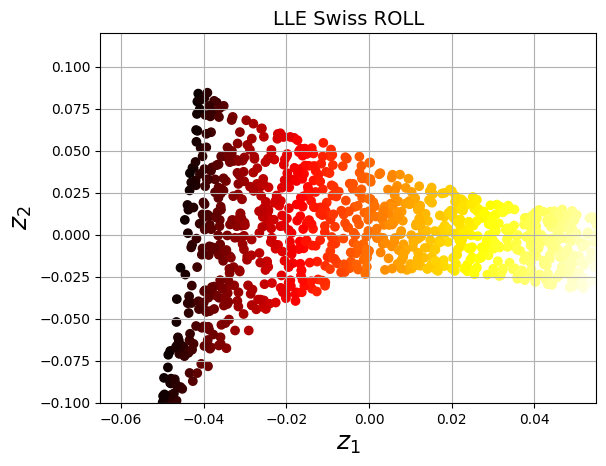

In [16]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=41)
Ile = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
Ile.fit (X)

LocallyLinearEmbedding(eigen_solver='auto', hessian_tol=0.001, max_iter=100,
                       method='standard', n_neighbors=10, n_jobs=None,
                       n_components=2, random_state=42,tol=1e-06)
X_reduced = Ile.transform(X)

plt.title("LLE Swiss ROLL", fontsize=14)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18)
plt.axis([-0.065,0.055,-0.1,0.12])
plt.grid(True)
plt.show()

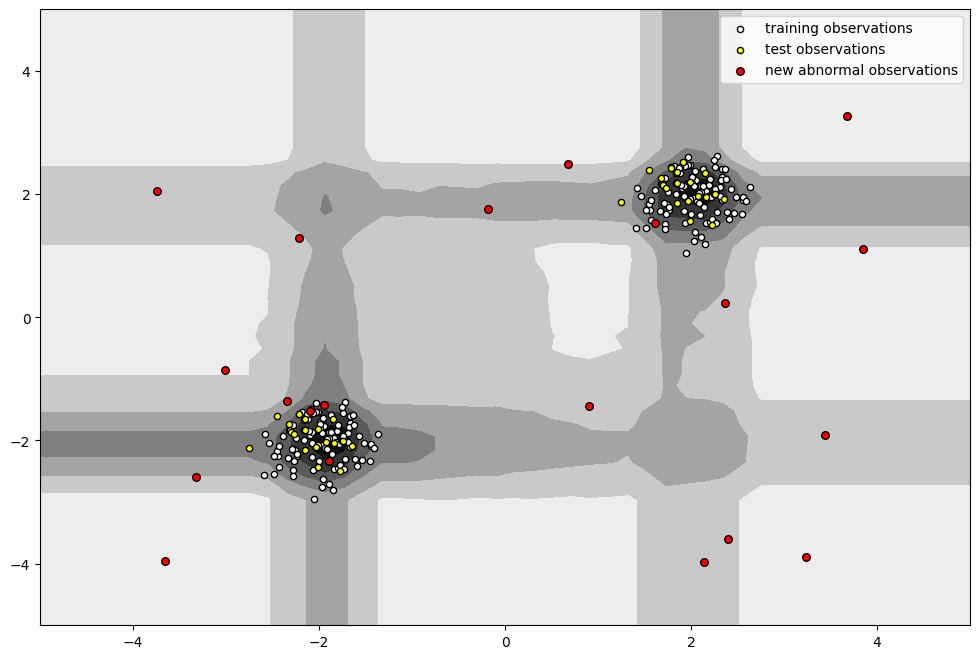

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

state_value = np.random.RandomState(20)

# train data
X = 0.3 * state_value.randn(100, 2)
X_train = np.r_[X + 2, X - 2]

# test data
X = 0.3 * state_value.randn(20, 2)
X_test = np.r_[X + 2, X - 2]

# outlier data
X_outliers = state_value.uniform(low=-4, high=4, size=(20, 2))

isol = IsolationForest(max_samples=100, random_state=state_value)

isol.fit(X_train)

y_pred_train = isol.predict(X_train)
y_pred_test = isol.predict(X_test)
y_pred_outliers = isol.predict(X_outliers)

xx, yy = np.meshgrid(
    np.linspace(-5, 5, 50),
    np.linspace(-5, 5, 50)
)

Z = isol.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.binary)

ob1 = plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c="white", s=20, edgecolors="k"
)

ob2 = plt.scatter(
    X_test[:, 0], X_test[:, 1],
    c="yellow", s=20, edgecolors="k"
)

ad = plt.scatter(
    X_outliers[:, 0], X_outliers[:, 1],
    c="red", s=30, edgecolors="k"
)

plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))

plt.legend(
    [ob1, ob2, ad],
    ["training observations", "test observations", "new abnormal observations"]
)

plt.show()

In [31]:
import pandas as pd
import numpy as np

breast_cancer = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')
breast_cancer.head()

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [33]:
breast_cancer.columns=["id_number", "clump_thickness", "unif_cell_size", "unif_cell_shape", "marg_adhesion", "single_epith_cell_size", "bare_nuclei", "bland_chromatin", "normal_nucleoli", "mitoses", "class"]
breast_cancer.head()

,id_number,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4


In [35]:
breast_cancer.info()
breast_cancer.isnull().values.sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id_number               698 non-null    int64 
 1   clump_thickness         698 non-null    int64 
 2   unif_cell_size          698 non-null    int64 
 3   unif_cell_shape         698 non-null    int64 
 4   marg_adhesion           698 non-null    int64 
 5   single_epith_cell_size  698 non-null    int64 
 6   bare_nuclei             698 non-null    object
 7   bland_chromatin         698 non-null    int64 
 8   normal_nucleoli         698 non-null    int64 
 9   mitoses                 698 non-null    int64 
 10  class                   698 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


np.int64(0)

In [38]:
breast_cancer['bare_nuclei']=breast_cancer['bare_nuclei'].replace('?',np.nan)
breast_cancer['bare_nuclei']=breast_cancer['bare_nuclei'].fillna(breast_cancer['bare_nuclei'].value_counts().index[0])
breast_cancer['cnacer_ind']=0
breast_cancer.loc[breast_cancer['class']==4,'cnacer_ind']=1

X = breast_cancer.drop(['id_number','class','cnacer_ind'],axis=1)
y = breast_cancer['cnacer_ind']


In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
y_pred = knn.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_pred))

0.9714285714285714
[[131   4]
 [  2  73]]
0.9718518518518519


In [52]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(knn,{'n_neighbors':[1,2,3,4,5]}, n_jobs=-1, cv=7, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

grid_search.best_params_
knn_best = grid_search.best_estimator_
y_pred = knn_best.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_pred))

0.9714285714285714
[[132   3]
 [  3  72]]
0.9688888888888889
